# Reading a REIMS acquisition with `wraw`

This notebook opens a private Waters RAW directory, inspects its run and function metadata, plots a representative mass spectrum, and calculates the full total-ion-current trace. The data itself is not distributed with the repository.

> **Dataset used in:** _Farahmand, M., Jamzad, A., Fooladgar, F. et al. FACT: foundation model for assessing cancer tissue margins with mass spectrometry. Int J CARS 20, 1097–1104 (2025). https://doi.org/10.1007/s11548-025-03355-8_

## Point the notebook at the private data


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import wraw

sns.set_theme(style="ticks", context="notebook")

raw_path = Path(r'D:\Datasets\Proprietory\REIMS\Skin\example.raw')
raw = wraw.read(raw_path)
function = raw.function(1)
raw.path.name

'example.raw'

## Run and function metadata

In [2]:
run_fields = {
    "File": raw.path.name,
    "Acquired name": raw.metadata.get("Acquired Name"),
    "Acquired date": raw.metadata.get("Acquired Date"),
    "Acquired time": raw.metadata.get("Acquired Time"),
    "Instrument": raw.metadata.get("Instrument"),
    "Polarity": raw.polarity,
    "Functions": len(raw.functions),
}
run_fields

{'File': 'example.raw',
 'Acquired name': 'Nodular_BCC_Day17_Jan21_2022_ClinicalCase108_exvivoburns_BCC_case5',
 'Acquired date': '21-Jan-2022',
 'Acquired time': '12:20:32',
 'Instrument': 'XEVO-G2XSQTOF#NotSet',
 'Polarity': 'ES-',
 'Functions': 1}

In [3]:
function_fields = {
    "Number": function.number,
    "Description": function.description,
    "Data format": function.data_format,
    "Scans": function.scan_count,
    "Mass range": f"{function.mass_range[0]:g}–{function.mass_range[1]:g} m/z",
    "Scan time": f"{function.scan_time_s:g} s",
    "Interscan time": f"{function.interscan_time_s:g} s",
    "Record encoding": function.encoding,
}
function_fields

{'Number': 1,
 'Description': 'TOF MS FUNCTION',
 'Data format': 'Continuum',
 'Scans': 750,
 'Mass range': '100–1200 m/z',
 'Scan time': '1 s',
 'Interscan time': '0.014 s',
 'Record encoding': 'bitpacked8'}

## A representative spectrum

Only the selected scan is read and decoded. Seaborn plots the arrays returned by `wraw` directly.

{'scan_index': 375,
 'retention_time_min': 6.376383304595947,
 'points': 240080,
 'tic': 149924884.0,
 'base_peak_mz': 554.2633056640625,
 'base_peak_intensity': 659044.0}

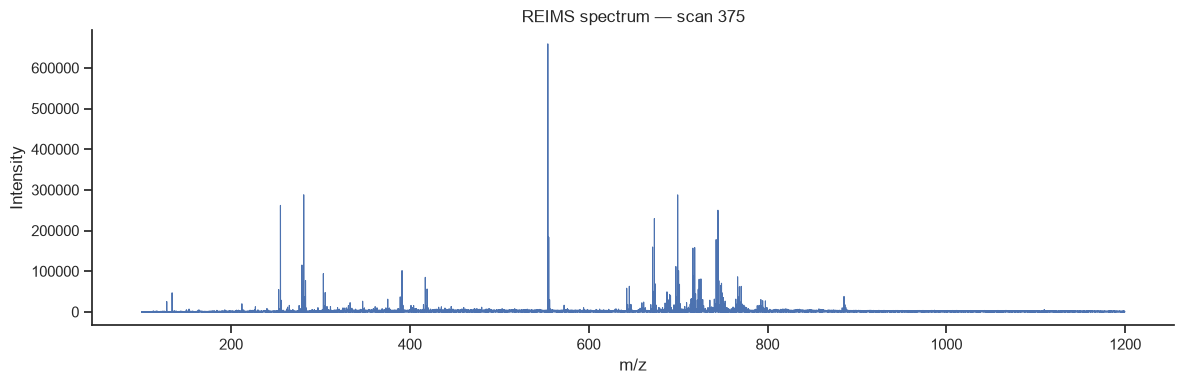

In [4]:
scan_index = function.scan_count // 2
spectrum = function.read_spectrum(scan_index)

spectrum_fields = {
    "scan_index": spectrum.scan_index,
    "retention_time_min": spectrum.retention_time_min,
    "points": spectrum.mz.size,
    "tic": spectrum.tic,
    "base_peak_mz": float(spectrum.mz[spectrum.base_peak_index]),
    "base_peak_intensity": float(spectrum.intensity[spectrum.base_peak_index]),
}
display(spectrum_fields)

figure, axis = plt.subplots(figsize=(12, 4))
sns.lineplot(x=spectrum.mz, y=spectrum.intensity, estimator=None, sort=False, linewidth=0.8, ax=axis)
axis.set(title=f"REIMS spectrum — scan {scan_index}", xlabel="m/z", ylabel="Intensity")
sns.despine()
figure.tight_layout()

## Chromatogram (Total ion current)

This acquisition is small enough to decode every scan while keeping memory use bounded. `iter_spectra()` yields one spectrum at a time.

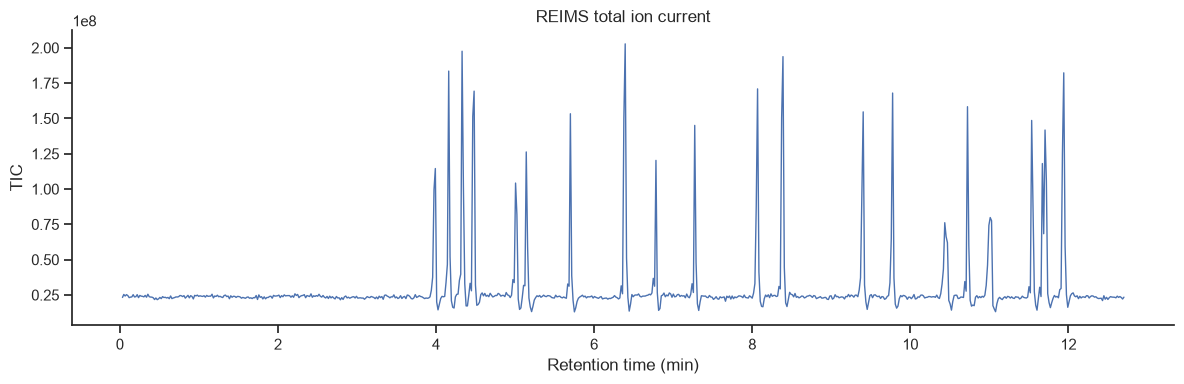

In [5]:
tic = np.fromiter((item.tic for item in function.iter_spectra()), dtype=float, count=function.scan_count)

figure, axis = plt.subplots(figsize=(12, 4))
sns.lineplot(x=function.retention_times, y=tic, estimator=None, sort=False, linewidth=1, ax=axis)
axis.set(title="REIMS total ion current", xlabel="Retention time (min)", ylabel="TIC")
sns.despine()
figure.tight_layout()